# Price Prediction using Regression

This is a tickets pricing monitoring system. It scrapes tickets pricing data periodically and stores it in a database. Ticket pricing changes based on demand and time, and there can be significant difference in price. We are creating this product mainly with ourselves in mind. Users can set up alarms using an email, choosing an origin and destination (cities), time (date and hour range picker) choosing a price reduction over mean price, etc.

**Following is the description for columns in the dataset**<br>
- insert_date: date and time when the price was collected and written in the database<br>
- origin: origin city <br>
- destination: destination city <br>
- start_date: train departure time<br>
- end_date: train arrival time<br>
- train_type: train service name<br>
- price: price<br>
- train_class: ticket class, tourist, business, etc.<br>
- fare: ticket fare, round trip, etc <br>

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline
sns.set()

#### **Task 1: Import Dataset and create a copy of that dataset**

In [7]:
#write code here
data = pd.read_csv("data1.csv")
df = data.copy() 

#### **Task 2: Display first five rows** 

In [8]:
#write code here
df.head()

,insert_date,origin,destination,start_date,end_date,train_type,price,train_class,fare
0,2019-04-11 21:49:46,MADRID,BARCELONA,2019-04-18 05:50:00,2019-04-18 08:55:00,AVE,68.95,Preferente,Promo
1,2019-04-11 21:49:46,MADRID,BARCELONA,2019-04-18 06:30:00,2019-04-18 09:20:00,AVE,75.40,Turista,Promo
2,2019-04-11 21:49:46,MADRID,BARCELONA,2019-04-18 07:00:00,2019-04-18 09:30:00,AVE,106.75,Turista Plus,Promo
3,2019-04-11 21:49:46,MADRID,BARCELONA,2019-04-18 07:30:00,2019-04-18 10:40:00,AVE,90.50,Turista Plus,Promo
4,2019-04-11 21:49:46,MADRID,BARCELONA,2019-04-18 08:00:00,2019-04-18 10:30:00,AVE,88.95,Turista,Promo


#### **Task 3: Check the number of rows and columns**

In [ ]:
#write code here
df.shape

(215909, 9)

#### **Task 4: Check data types of all columns**

In [ ]:
#write code here
df.dtypes

insert_date     object
origin          object
destination     object
start_date      object
end_date        object
train_type      object
price          float64
train_class     object
fare            object
dtype: object

#### **Task 5: Check summary statistics**

In [ ]:
#write code here
df.describe()

,price
count,202321.000000
mean,56.723877
std,25.531787
min,16.600000
25%,28.350000
50%,53.400000
75%,76.300000
max,206.800000


#### **Task 6: Check summary statistics of all columns, including object dataypes**

In [ ]:
df.describe(include='all')

,insert_date,origin,destination,start_date,end_date,train_type,price,train_class,fare
count,215909,215909,215909,215909,215909,215909,202321.000000,215266,215266
unique,30543,5,5,2231,2870,16,NaN,5,5
top,2019-05-09 15:02:02,MADRID,MADRID,2019-06-02 17:30:00,2019-06-02 23:03:00,AVE,NaN,Turista,Promo
freq,90,110440,105469,2089,1278,126577,NaN,164016,132065
mean,NaN,NaN,NaN,NaN,NaN,NaN,56.723877,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,25.531787,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,16.600000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,28.350000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,53.400000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,76.300000,NaN,NaN


**Question: Explain the summary statistics for the above data set**

**Answer:**
The highest number of tickets were collected on 2019-05-09 15:02:02 out of the 30543 unique date and time. Majority of the train travel was from Madrid and the destination was frequently Madrid. The train departure time was commonly 2019-06-02 17:30:00 and the train arrival time was typically 2019-06-02 23:03:00. The train type used extensively was AVE while the train class utilized often was Turista. The average price of train was 56.72 and the ticket fare predominantly used was Promo.

#### **Task 7: Check null values in dataset**

In [ ]:
#write code here
df.isnull().sum()

insert_date        0
origin             0
destination        0
start_date         0
end_date           0
train_type         0
price          13588
train_class      643
fare             643
dtype: int64

#### **Task 8: Fill the Null values in the 'price' column.**<br>
*Hint: Take mean*

In [ ]:
#write code here
df['price'] = df['price'].fillna(df['price'].mean())

#### **Task 9: Drop the rows containing Null values in the attributes train_class and fare**

In [ ]:
#write code here
df.dropna(subset=['train_class','fare'],inplace=True)

#### **Task 10: Drop 'insert_date'**

In [ ]:
#write code here
df.drop('insert_date',axis=1,inplace=True)

**Check null values again in dataset**

In [ ]:
#write code here
df.isnull().sum()

origin         0
destination    0
start_date     0
end_date       0
train_type     0
price          0
train_class    0
fare           0
dtype: int64

#### **Task 11: Plot number of people boarding from different stations**


<Axes: xlabel='origin', ylabel='count'>

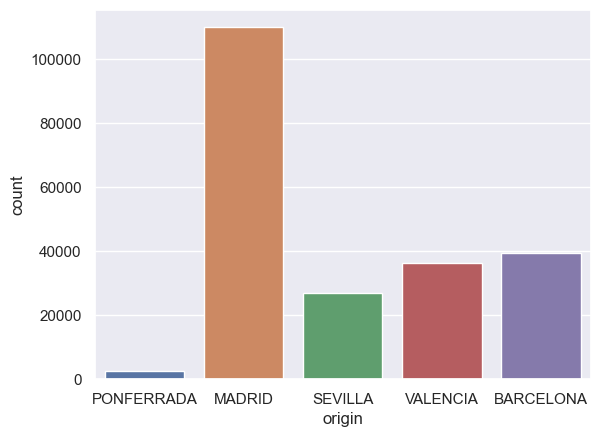

In [ ]:
#write code here
sns.countplot(data=df,x='origin',hue='origin')

**Question: What insights do you get from the above plot?**

**Answer:**
The plot shows that the origin city "MADRID" is the most frequent while the origin city "PONFERRADA" is the least frequent. There are several other origin cities such as "SEVILLA", "BARCELONA", and "VALENCIA".

#### **Task 12: Plot number of people for the destination stations**


<Axes: xlabel='destination', ylabel='count'>

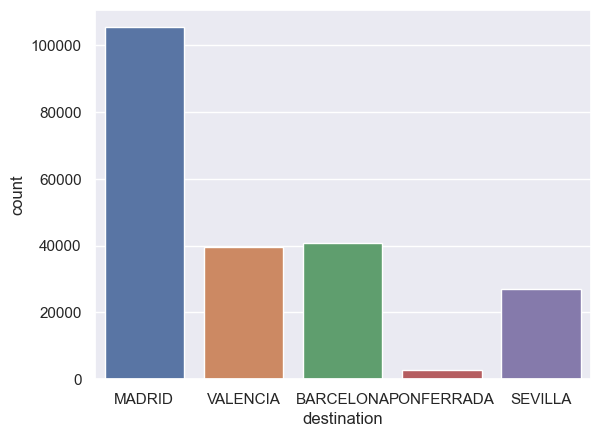

In [ ]:
#write code here
sns.countplot(data=df,x='destination',hue='destination')

**Question: What insights do you get from the above graph?**

**Answer:**
The plot shows that the destination city "MADRID" is the most frequent while the destination city "PONFERRADA" is the least frequent. There are several other origin cities such as "SEVILLA", "BARCELONA", and "VALENCIA".

#### **Task 13: Plot different types of train that runs in Spain**


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
 [Text(0, 0, 'MD-AVE'),
  Text(1, 0, 'MD-LD'),
  Text(2, 0, 'ALVIA'),
  Text(3, 0, 'REGIONAL'),
  Text(4, 0, 'AVE'),
  Text(5, 0, 'INTERCITY'),
  Text(6, 0, 'AVE-MD'),
  Text(7, 0, 'AVE-LD'),
  Text(8, 0, 'R. EXPRES'),
  Text(9, 0, 'AVE-TGV'),
  Text(10, 0, 'AV City'),
  Text(11, 0, 'MD'),
  Text(12, 0, 'LD-MD'),
  Text(13, 0, 'LD'),
  Text(14, 0, 'LD-AVE'),
  Text(15, 0, 'TRENHOTEL')])

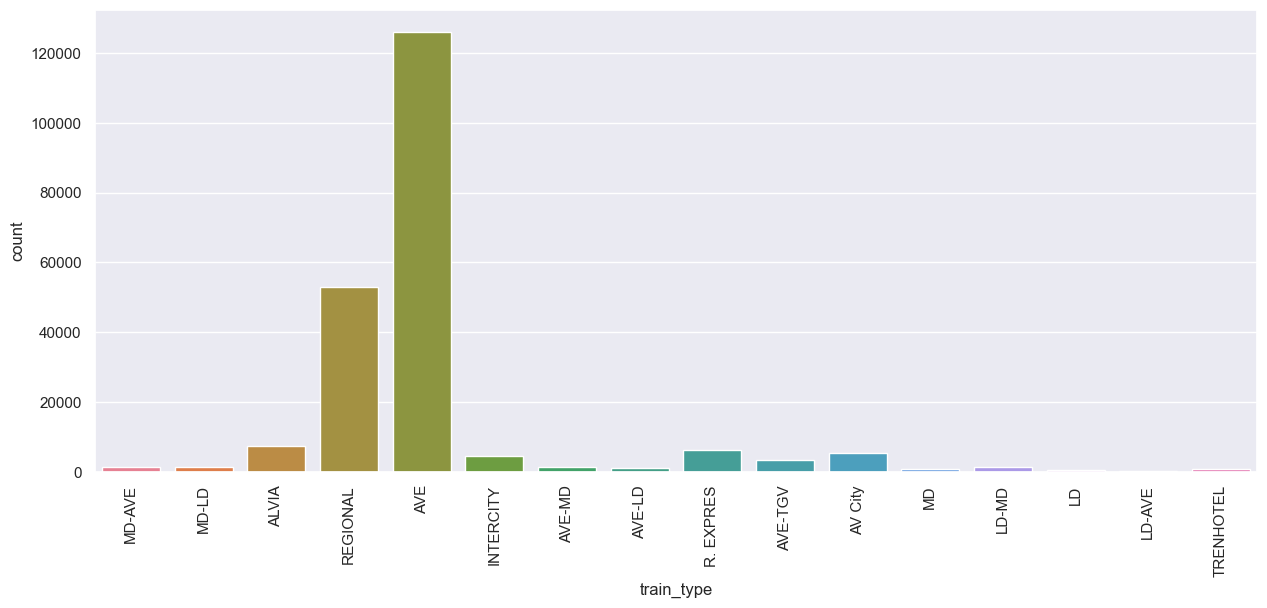

In [ ]:
#write code here
plt.figure(figsize=(15,6))
sns.countplot(data=df,x='train_type',hue='train_type')
plt.xticks(rotation=90)

**Question: Which train runs the maximum in number as compared to other train types?**

**Answer:** 
AVE train runs the maximum in number

#### **Task 14: Plot number of trains of different class**


<Axes: xlabel='train_class', ylabel='count'>

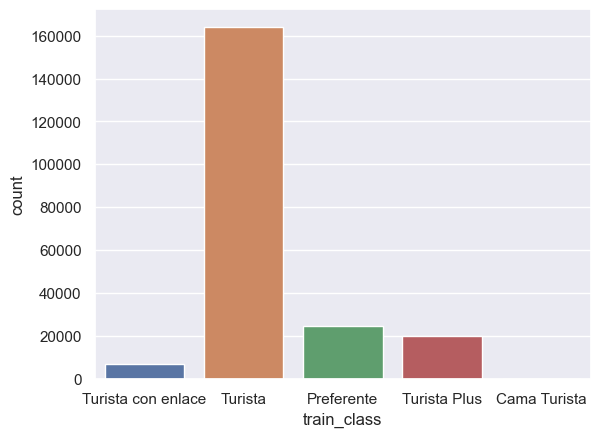

In [ ]:
#write code here
sns.countplot(data=df,x='train_class',hue='train_class')

**Question: Which the most common train class for traveling among people in general?**

**Answer:** 
Turista is the most common train class for travelling among people.

#### **Task 15: Plot number of tickets bought from each category**


<Axes: xlabel='fare', ylabel='count'>

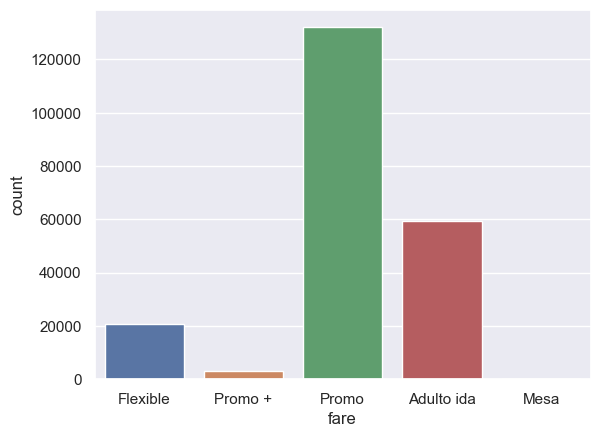

In [ ]:
#write code here
sns.countplot(data=df,x='fare',hue='fare')

**Question: Which the most common tickets are bought?**

**Answer:**
Promo is the most common tickets that are bought  

#### **Task 16: Plot distribution of the ticket prices**

<Axes: xlabel='price', ylabel='Count'>

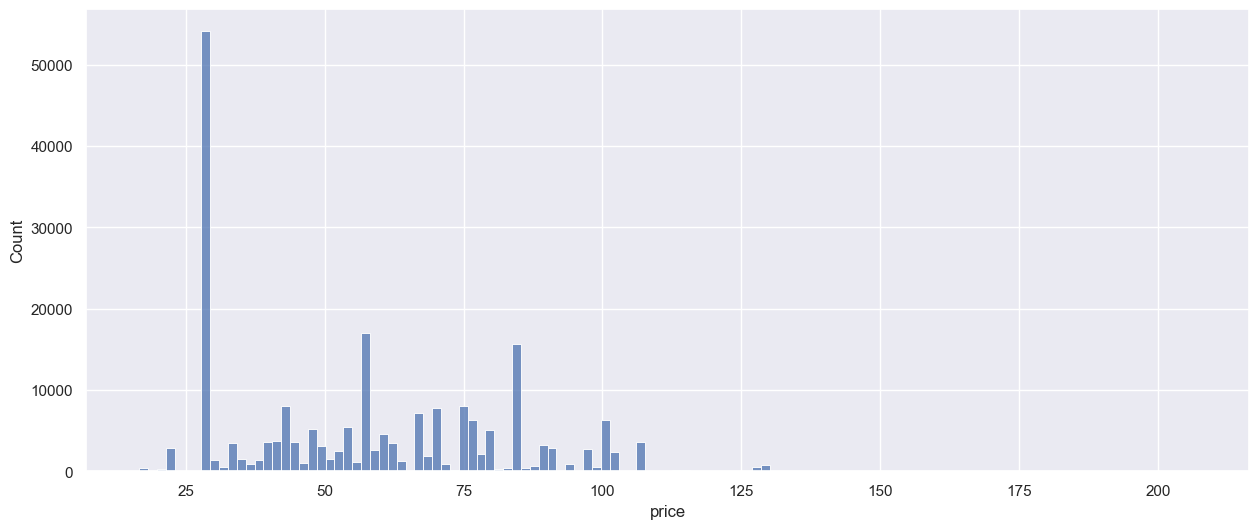

In [ ]:
#write code here
plt.figure(figsize=(15,6))
sns.histplot(df['price'])

**Question: What readings can you get from the above plot?**

**Answer:**
There is a very prominent peak at the lowest price range around 25, indicating that this price point has the highest count by a significant margin compared to all other price levels.
The frequency drops off sharply as the price increases, with only a few data points or occurrences at higher price levels above 100          

###### **Task 17: Show train_class vs price through boxplot**

<Axes: xlabel='train_class', ylabel='price'>

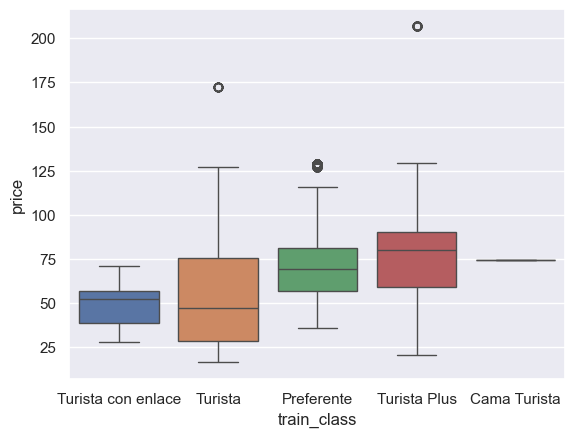

In [ ]:
#write code here
sns.boxplot(data=df,x='train_class',y='price',hue='train_class')

**Question: What pricing trends can you find out by looking at the plot above?**

**Answer:**
Turista Plus has the highest median from all the train classes while Turista has the lowest median.
Turista and Turista Plus have one outlier and Preferente has a couple of outliers.
The prices are the most spread out in the Turista train class. 

#### **Task 18: Show train_type vs price through boxplot**


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
 [Text(0, 0, 'MD-AVE'),
  Text(1, 0, 'MD-LD'),
  Text(2, 0, 'ALVIA'),
  Text(3, 0, 'REGIONAL'),
  Text(4, 0, 'AVE'),
  Text(5, 0, 'INTERCITY'),
  Text(6, 0, 'AVE-MD'),
  Text(7, 0, 'AVE-LD'),
  Text(8, 0, 'R. EXPRES'),
  Text(9, 0, 'AVE-TGV'),
  Text(10, 0, 'AV City'),
  Text(11, 0, 'MD'),
  Text(12, 0, 'LD-MD'),
  Text(13, 0, 'LD'),
  Text(14, 0, 'LD-AVE'),
  Text(15, 0, 'TRENHOTEL')])

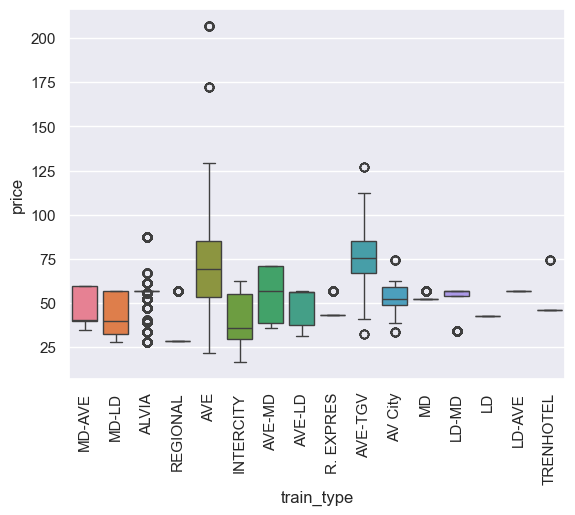

In [ ]:
#write code here
sns.boxplot(data=df,x='train_type',y='price',hue='train_type')
plt.xticks(rotation=90)

**Question: Which type of trains cost more as compared to others?**

**Answer:** 
AVE-TGV train type costs more as compared to others as it has the highest median.


## Feature Engineering


In [ ]:
df = df.reset_index()

**Finding the travel time between the place of origin and destination**<br>
We need to find out the travel time for each entry which can be obtained from the 'start_date' and 'end_date' column. Also if you see, these columns are in object type therefore datetimeFormat should be defined to perform the necessary operation of getting the required time.

**Import datetime library**

In [ ]:
#write code here
import datetime

In [ ]:
datetimeFormat = '%Y-%m-%d %H:%M:%S'
def fun(a,b):
    diff = datetime.datetime.strptime(b, datetimeFormat)- datetime.datetime.strptime(a, datetimeFormat)
    return(diff.seconds/3600.0)                  
    

In [ ]:
df['travel_time_in_hrs'] = df.apply(lambda x:fun(x['start_date'],x['end_date']),axis=1) 

#### **Task 19: Remove redundant features**


**You need to remove features that are giving the related values as  'travel_time_in_hrs'**<br>
*Hint: Look for date related columns*

In [ ]:
#write code here
df.drop(['start_date','end_date'],axis=1,inplace=True)

We now need to find out the pricing from 'MADRID' to other destinations. We also need to find out time which each train requires for travelling. 

## **Travelling from MADRID to SEVILLA**

#### Task 20: Findout people travelling from MADRID to SEVILLA

In [ ]:
#write code here
df1 = df[(df['origin'] == 'MADRID') & (df['destination'] == 'SEVILLA')]

#### Task 21: Make a plot for finding out travelling hours for each train type

<Axes: xlabel='train_type', ylabel='travel_time_in_hrs'>

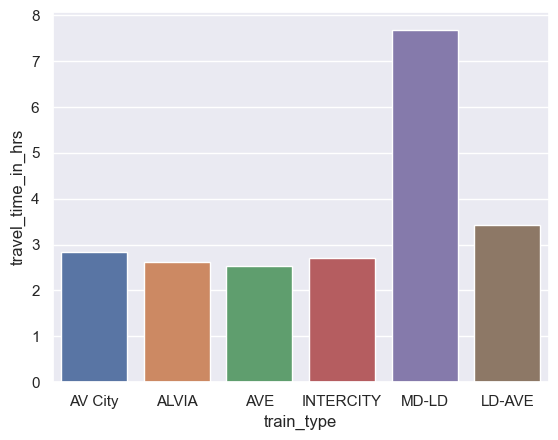

In [ ]:
#write code here
sns.barplot(data=df1,x='train_type',y='travel_time_in_hrs',hue='train_type')

#### **Task 22: Show train_type vs price through boxplot**


<Axes: xlabel='train_type', ylabel='price'>

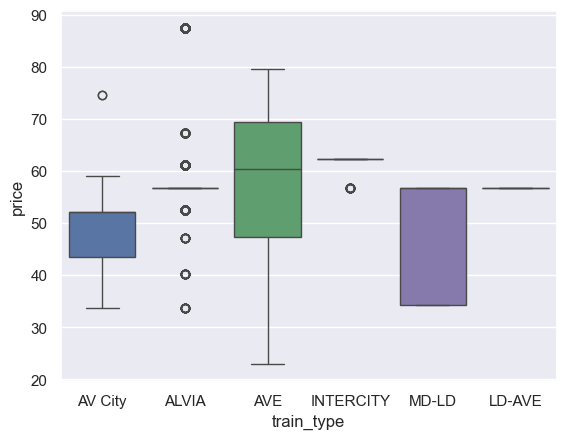

In [ ]:
#write code here
sns.boxplot(data=df1,x='train_type',y='price',hue='train_type')

## **Travelling from MADRID to BARCELONA**


#### Task 23: Findout people travelling from MADRID to BARCELONA

In [ ]:
#write code here
df1 = df[(df['origin'] == 'MADRID') & (df['destination'] == 'BARCELONA')]

#### Task 24: Make a plot for finding out travelling hours for each train type

<Axes: xlabel='train_type', ylabel='travel_time_in_hrs'>

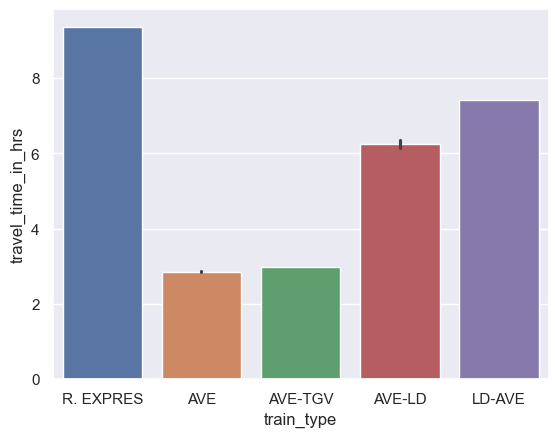

In [ ]:
#write code here
sns.barplot(data=df1,x='train_type',y='travel_time_in_hrs',hue='train_type')

#### **Task 25: Show train_type vs price through boxplot**

<Axes: xlabel='train_type', ylabel='price'>

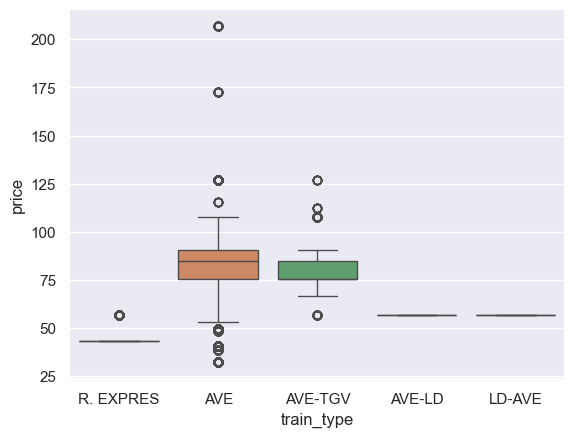

In [ ]:
#write code here
sns.boxplot(data=df1,x='train_type',y='price',hue='train_type')

## **Travelling from MADRID to VALENCIA**

#### Task 26: Findout people travelling from MADRID to VALENCIA

In [ ]:
#write code here
df1 = df[(df['origin'] == 'MADRID') & (df['destination'] == 'VALENCIA')]

#### Task 27: Make a plot for finding out travelling hours for each train type

<Axes: xlabel='train_type', ylabel='travel_time_in_hrs'>

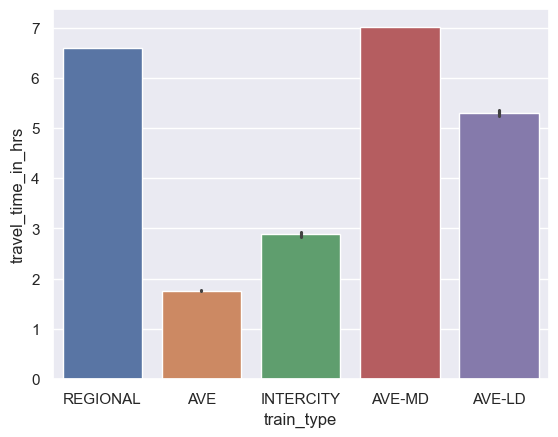

In [ ]:
#write code here
sns.barplot(data=df1,x='train_type',y='travel_time_in_hrs',hue='train_type')

#### **Task 28: Show train_type vs price through boxplot**

<Axes: xlabel='train_type', ylabel='price'>

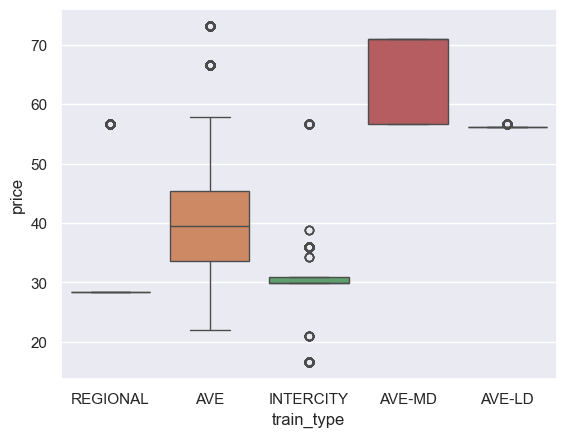

In [ ]:
#write code here
sns.boxplot(data=df1,x='train_type',y='price',hue='train_type')

## **Travelling from MADRID to PONFERRADA**

#### Task 29: Findout people travelling from MADRID to PONFERRADA

In [ ]:
#write code here
df1 = df[(df['origin'] == 'MADRID') & (df['destination'] == 'PONFERRADA')]

#### Task 30: Make a plot for finding out travelling hours for each train type

<Axes: xlabel='train_type', ylabel='travel_time_in_hrs'>

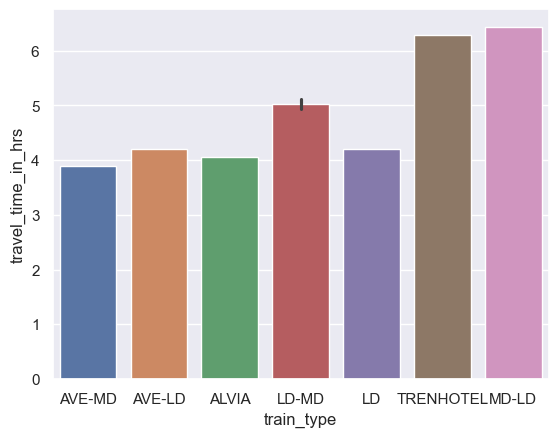

In [ ]:
#write code here
sns.barplot(data=df1,x='train_type',y='travel_time_in_hrs',hue='train_type')

#### **Task 31: Show train_type vs price through boxplot**

<Axes: xlabel='train_type', ylabel='price'>

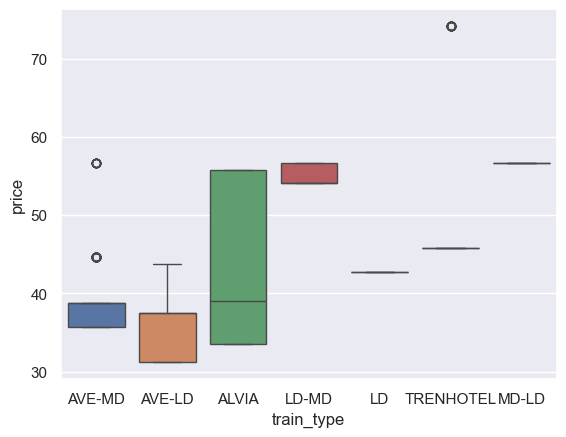

In [ ]:
#write code here
sns.boxplot(data=df1,x='train_type',y='price',hue='train_type')

# Applying Linear  Regression

#### Task 32: Import LabelEncoder library from sklearn 

In [ ]:
#write code here
from sklearn.preprocessing import LabelEncoder

**Data Encoding**

In [ ]:
lab_en = LabelEncoder()
df.iloc[:,1] = lab_en.fit_transform(df.iloc[:,1])
df.iloc[:,2] = lab_en.fit_transform(df.iloc[:,2])
df.iloc[:,3] = lab_en.fit_transform(df.iloc[:,3])
df.iloc[:,5] = lab_en.fit_transform(df.iloc[:,5])
df.iloc[:,6] = lab_en.fit_transform(df.iloc[:,6])

In [ ]:
df.head()

,index,origin,destination,train_type,price,train_class,fare,travel_time_in_hrs
0,0,2,1,11,59.50,4,1,4.700000
1,1,2,1,11,34.65,4,4,5.800000
2,2,2,1,12,39.95,4,4,5.916667
3,3,2,1,11,40.60,4,4,4.983333
4,4,2,1,0,27.90,2,3,4.133333


#### Task 33: Separate the dependant and independant variables

In [ ]:
#write code here
X = df.drop('price',axis=1)
Y = df[['price']]

#### Task 34: Import test_train_split from sklearn

In [ ]:
#write code here
from sklearn.model_selection import train_test_split

#### Task 35:**Split the data into training and test set**

In [ ]:
#write code here
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,train_size=0.8,shuffle=True)

#### Task 36: Import LinearRegression library from sklearn

In [ ]:
#write code here
from sklearn.linear_model import LinearRegression

#### Task 37: Make an object of LinearRegression( ) and train it using the training data set

In [ ]:
#write code here
lr = LinearRegression()

In [ ]:
#write code here
lr.fit(X_train,Y_train)

LinearRegression()

#### Task 38: Find out the predictions using test data set.

In [ ]:
#write code here
lr_predict = lr.predict(X_test)

#### Task 39: Find out the predictions using training data set.

In [ ]:
#write code here
lr_predict_train = lr.predict(X_train)

#### Task 40: Import r2_score library form sklearn

In [ ]:
#write code here
from sklearn.metrics import r2_score

#### Task 41: Find out the R2 Score for test data and print it.

In [ ]:
#write code here
lr_r2_test= r2_score(Y_test,lr_predict)

#### Task 42: Find out the R2 Score for training data and print it.

In [ ]:
lr_r2_train = r2_score(Y_train,lr_predict_train)

Comaparing training and testing R2 scores

In [ ]:
print('R2 score for Linear Regression Testing Data is: ', lr_r2_train)
print('R2 score for Linear Regression Testing Data is: ', lr_r2_test)

R2 score for Linear Regression Testing Data is:  0.7249050933563834
R2 score for Linear Regression Testing Data is:  0.728221883336545


# Applying Polynomial Regression

#### Task 43: Import PolynomialFeatures from sklearn

In [ ]:
#write code here
from sklearn.preprocessing import PolynomialFeatures

#### Task 44: Make and object of default Polynomial Features

In [ ]:
#write code here
poly_reg = PolynomialFeatures(degree=2)

#### Task 45: Transform the features to higher degree features.

In [ ]:
#write code here
poly_reg.fit(X_train)
X_train_poly = poly_reg.transform(X_train)
X_test_poly = poly_reg.transform(X_test)

#### Task 46: Fit the transformed features to Linear Regression

In [ ]:
#write code here
poly_model = LinearRegression()
poly_model.fit(X_train_poly, Y_train)

LinearRegression()

#### Task 47: Find the predictions on the data set

In [ ]:
#write code here
y_train_predicted,y_test_predict = poly_model.predict(X_train_poly),poly_model.predict(X_test_poly)

#### Task 48: Evaluate R2 score for training data set

In [ ]:
#evaluating the model on training dataset
#write code here
r2_train = r2_score(Y_train,y_train_predicted)

#### Task 49: Evaluate R2 score for test data set

In [ ]:
# evaluating the model on test dataset
#write code here
r2_test = r2_score(Y_test,y_test_predict)

Comaparing training and testing R2 scores

In [ ]:
#write code here
print ('The r2 score for training set is: ',r2_train)
print ('The r2 score for testing set is: ',r2_test)

The r2 score for training set is:  0.8207294100497117
The r2 score for testing set is:  0.8235637362701328


#### Task 50: Select the best model

**Question: Which model gives the best result for price prediction? Find out the complexity using R2 score and give your answer.**<br>
*Hint: Use for loop for finding the best degree and model complexity for polynomial regression model*

In [ ]:
#write code here
r2_train=[]
r2_test=[]
for i in range(1,6):
    poly_reg = PolynomialFeatures(degree=i)
    
    poly_reg.fit(X_train)
    X_tr_poly = poly_reg.transform(X_train)
    X_tst_poly = poly_reg.transform(X_test)
    
    poly = LinearRegression()
    poly.fit(X_tr_poly, Y_train)
   
    y_tr_predicted,y_tst_predict = poly.predict(X_tr_poly),poly.predict(X_tst_poly)
    r2_train.append(r2_score(Y_train, y_tr_predicted))
    r2_test.append(r2_score(Y_test, y_tst_predict))
    
print ('R2 Train', r2_train)
print ('R2 Test', r2_test)

R2 Train [0.7249050933563834, 0.8207294100497117, 0.8046713326089167, 0.7072133592822554, 0.6137908278301408]
R2 Test [0.7282218833365448, 0.8235637362701328, 0.8069269748935788, 0.7086442913656184, 0.6162103209784336]


#### Plotting the model

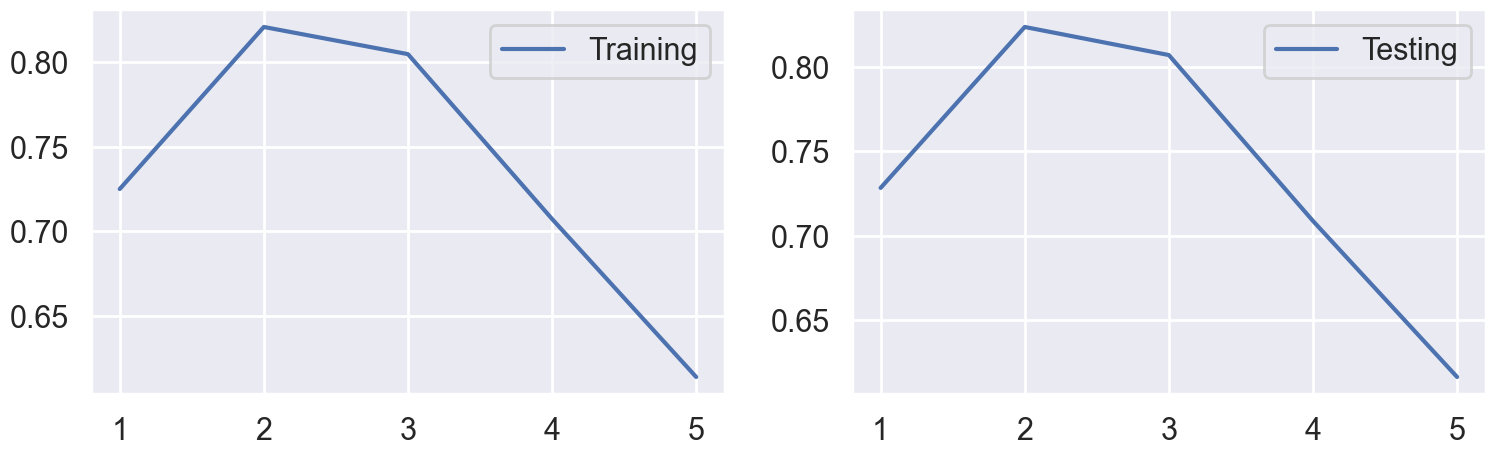

In [ ]:
plt.figure(figsize=(18,5))
sns.set_context('poster')
plt.subplot(1,2,1)
sns.lineplot(x=list(range(1,6)), y=r2_train, label='Training');
plt.subplot(1,2,2)
sns.lineplot(x=list(range(1,6)), y=r2_test, label='Testing');

**Answer**
 The model with a complexity of 2 should be selected as it appears to offer the best trade-off between fitting the training data well and generalizing to the testing data, without overfitting or underfitting.